Уже идёт весна, и ваш руководитель курса по питону Николай трясётся под одеялом, т.к. у него аллергия на цветение берёзы. Уже скоро будут чесаться глаза и потечёт ручей...


Помогите ему собрать новую аптечку, чтобы пережить апрель и май :)

# Часть 1. Анализ датасетов. 1 балл.

На диске в папке "Домашние задания" лежат три таблички в формате csv с товарами в разных аптеках.

Загрузи их в этот ноутбук и изучи. Ответь на следующие вопросы:
- Какие есть столбцы в этих датафреймах?
- Сколько значений в каждом датафрейме? Есть ли повторы внутри каждого датафрейма и между датафреймами?
- Все ли ячейки заполнены? Если нет, можем ли мы их заполнить?

In [ ]:
1. Столбцы: в 3 и 2: Стобец под номера (не подписан), Наименование, Цена, Производитель
Столбцы в 1 те же самые, но есть стобцы под магазины номеров от 1 по 9
2. 
Вывод программы:
=== Аптека 1 ===
Количество строк: 598
Столбцы: ['Unnamed: 0', 'Наименование', 'Магазин № 3', 'Магазин № 4', 'Магазин № 5', 'Магазин № 6', 'Магазин № 7', 'Магазин № 8', 'Магазин № 9']
Пропущенные значения:
Unnamed: 0        0
Наименование      0
Магазин № 3     505
Магазин № 4     476
Магазин № 5     498
Магазин № 6     511
Магазин № 7     526
Магазин № 8     527
Магазин № 9     538
dtype: int64


=== Аптека 2 ===
Количество строк: 164
Столбцы: ['Unnamed: 0', 'Наименование', 'Цена', 'Производитель']
Пропущенные значения:
Unnamed: 0       0
Наименование     0
Цена             0
Производитель    0
dtype: int64


=== Аптека 3 ===
Количество строк: 93
Столбцы: ['Unnamed: 0', 'Наименование', 'Цена', 'Производитель']
3. Очень много пропущенных значений в 1 аптеке в контексте магазинов, где, препарат вероятно отсутсвует. Можно заполнить подходящим зачением,
условно символизирующим это: 0 или -1.
Код:



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re

first = pd.read_csv('pharmacy1.csv')
second = pd.read_csv('pharmacy2.csv')
third = pd.read_csv('pharmacy3.csv')

print("=== Аптека 1 ===")
print(f"Количество строк: {len(first)}")
print(f"Столбцы: {first.columns.tolist()}")
print(f"Пропущенные значения:\n{first.isnull().sum()}")
print("\n")

print("=== Аптека 2 ===")
print(f"Количество строк: {len(second)}")
print(f"Столбцы: {second.columns.tolist()}")
print(f"Пропущенные значения:\n{second.isnull().sum()}")
print("\n")

print("=== Аптека 3 ===")
print(f"Количество строк: {len(third)}")
print(f"Столбцы: {third.columns.tolist()}")



# Часть 2. Визуализация. 2 балла.

Построй минимум 5 **различных** информативных графиков, основанных на данных в табличках.

Не забудь:
- подписать оси
- подписать название
- сохранять информативность графиков.

Какую информацию о ценах в аптеках можно получить из этих графиков?

Произведём разные графики по возможным информационным параметрам:
Информацию, которую можно получить, можно понять по названиям графиков
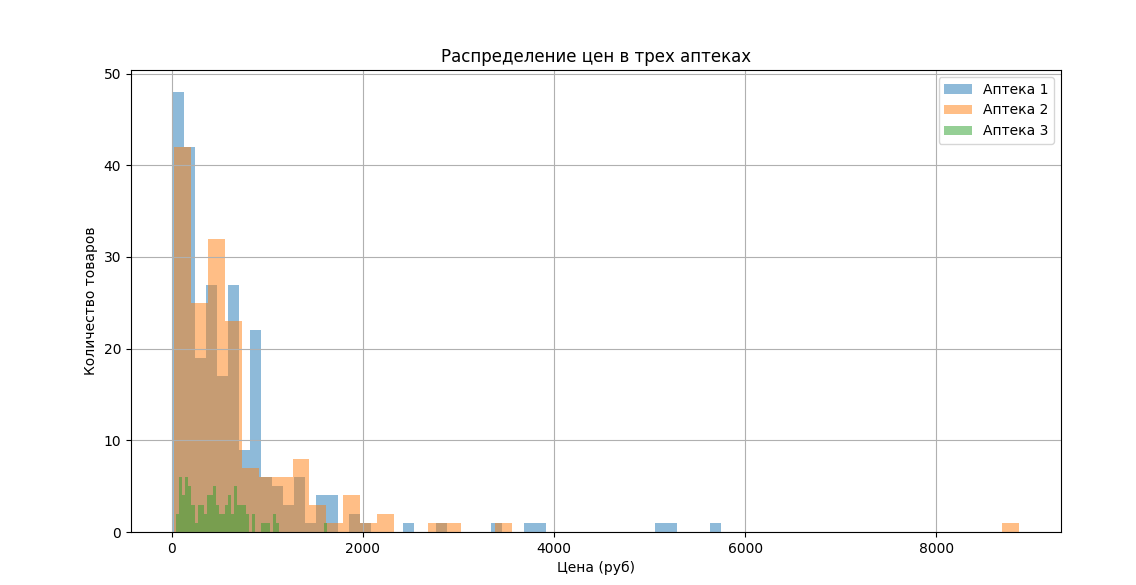
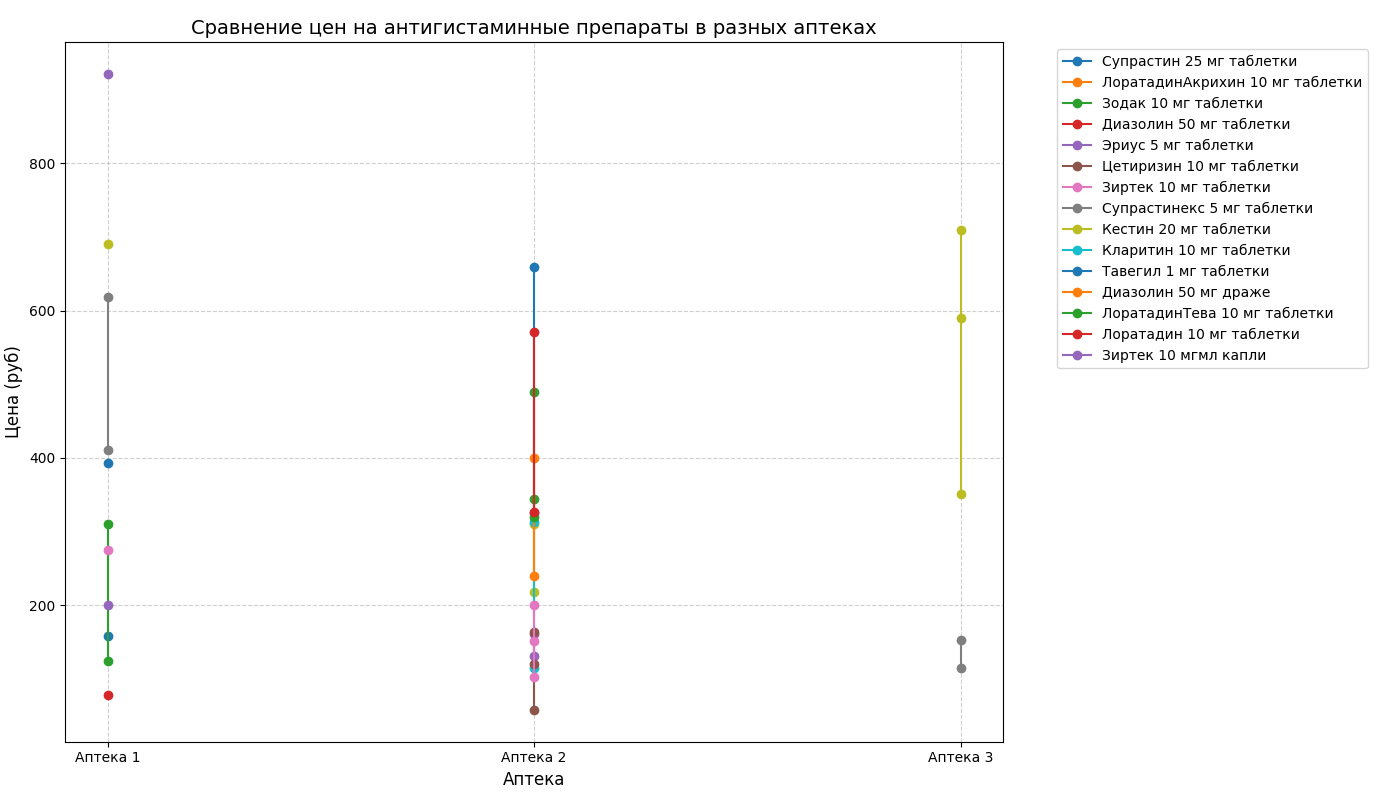
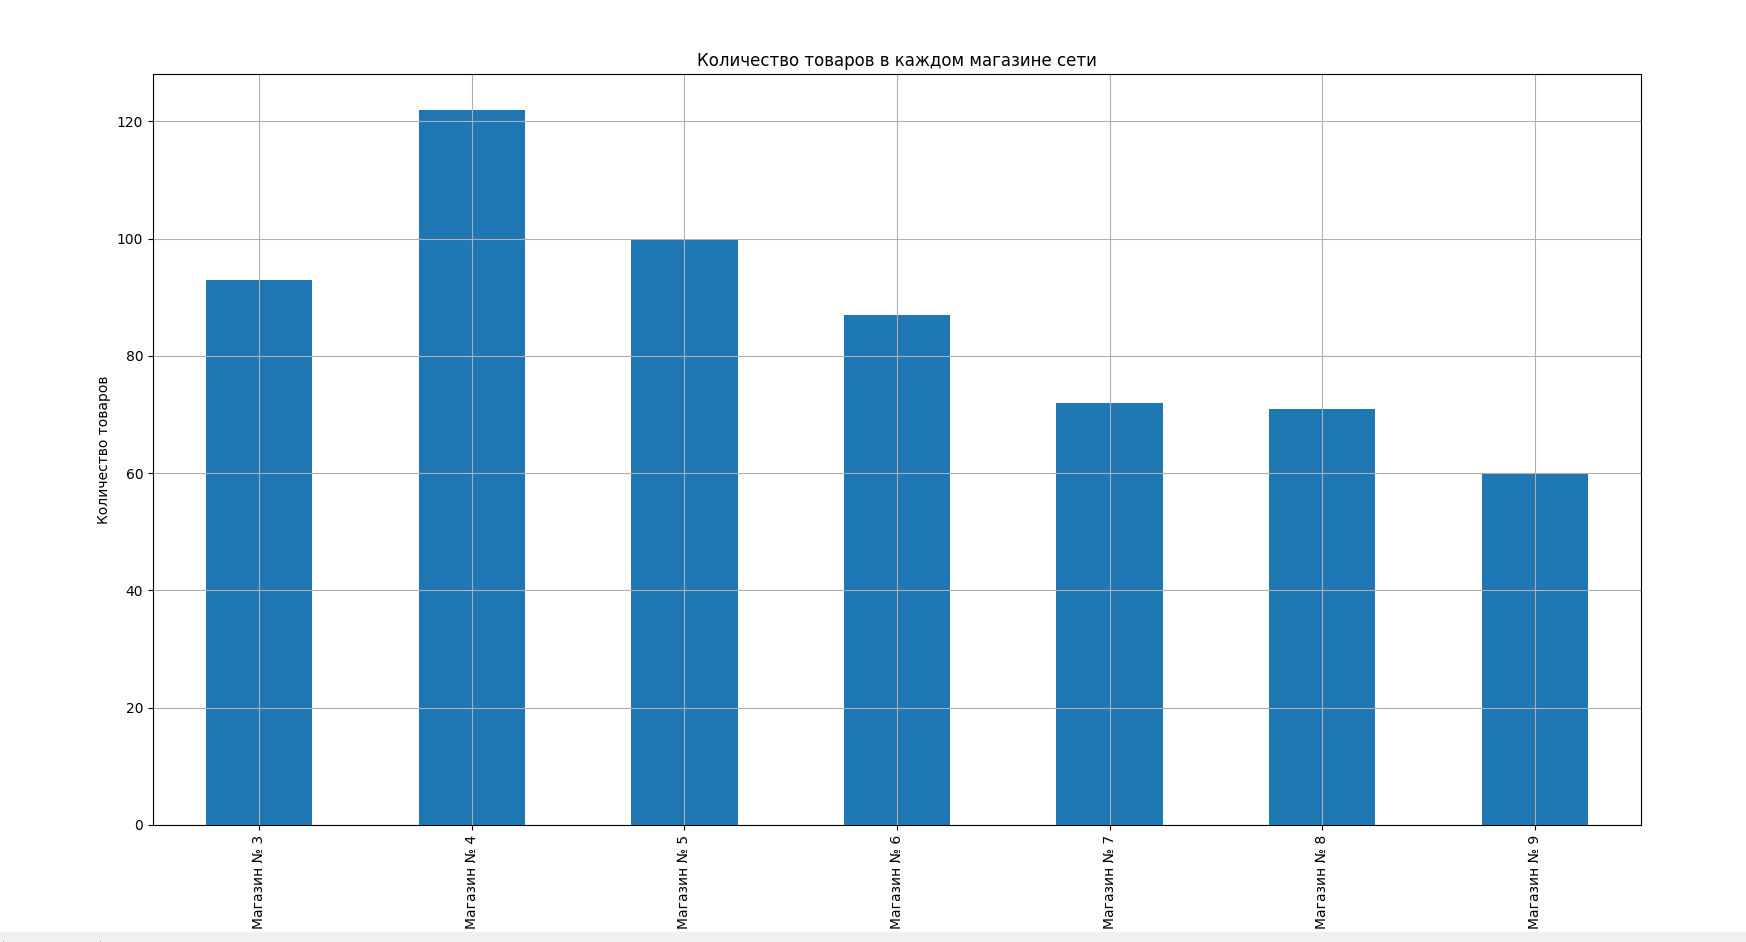
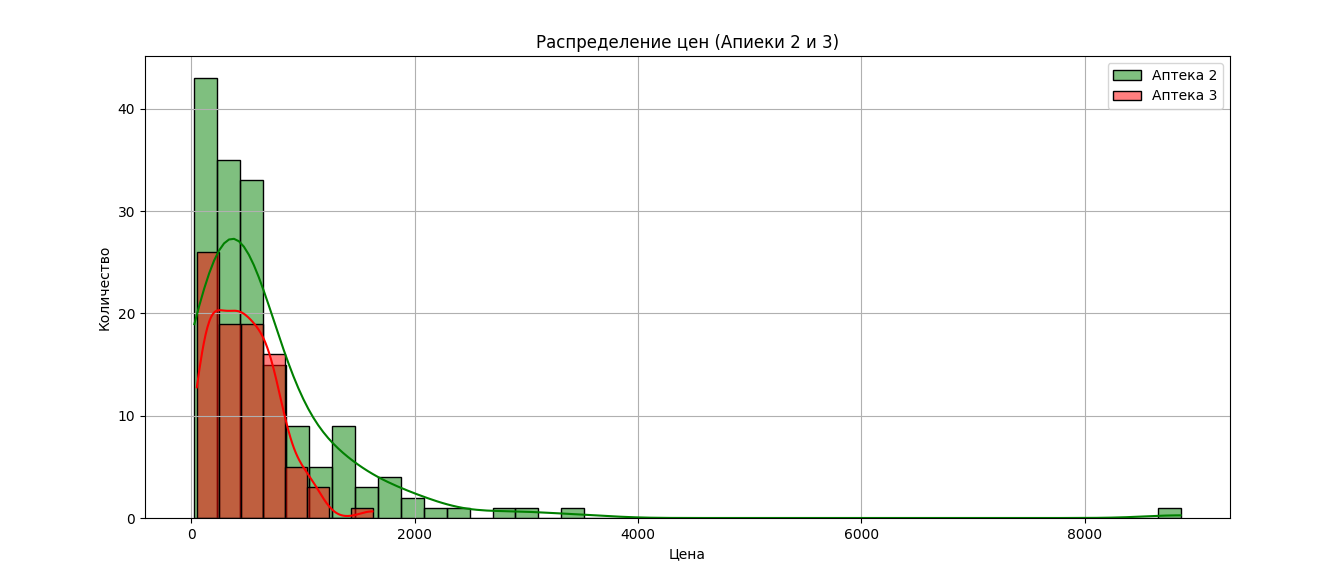
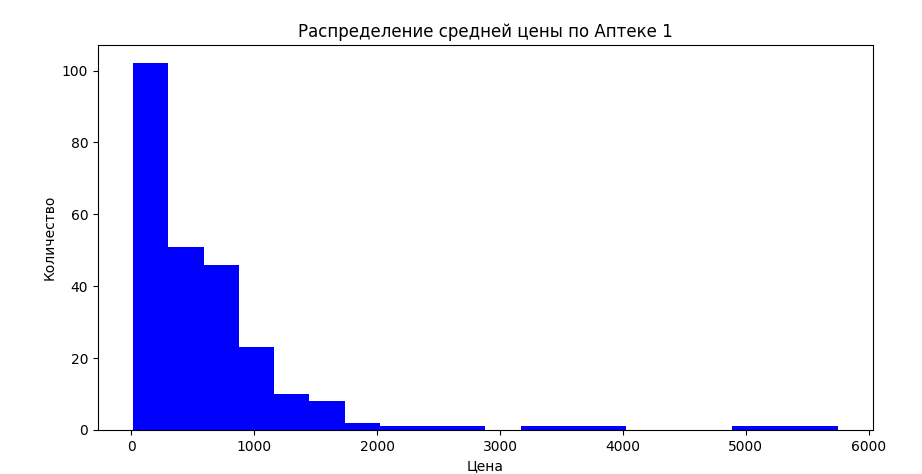

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re
import seaborn as sns

def convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    try:
        price_str = str(price_str).replace(' ', '').replace('₽', '').replace('руб', '').replace(',', '.')
        price_str = re.sub(r'[^\d.-]', '', price_str)
        return float(price_str)
    except:
        return np.nan


first = pd.read_csv('pharmacy1.csv')
second = pd.read_csv('pharmacy2.csv')
third = pd.read_csv('pharmacy3.csv')
for col in first.columns[2:9]:
    first[col] = first[col].apply(convert_price)

second['Цена'] = second['Цена'].apply(convert_price)
third['Цена'] = third['Цена'].apply(convert_price)

first['Средняя цена'] = first.iloc[:, 2:9].mean(axis=1, skipna=True)

#График 1
plt.figure(figsize=(12, 6))
plt.hist(first['Средняя цена'].dropna(), bins=50, alpha=0.5, label='Аптека 1')
plt.hist(second['Цена'].dropna(), bins=50, alpha=0.5, label='Аптека 2')
plt.hist(third['Цена'].dropna(), bins=50, alpha=0.5, label='Аптека 3')
plt.title('Распределение цен в трех аптеках')
plt.xlabel('Цена (руб)')
plt.ylabel('Количество товаров')
plt.legend()
plt.grid(True)
plt.show()



#График 2
# Список основных антигистаминных препаратов 
antihistamines = ['Лоратадин', 'Цетиризин', 'Дезлоратадин', 'Фексофенадин', 
    'Левоцетиризин', 'Супрастин', 'Диазолин', 'Тавегил', 
    'Кестин', 'Эриус', 'Зиртек', 'Зодак', 'Кларитин']


def is_antihistamine(name):
    name = str(name).lower()
    return any(antihist.lower() in name for antisthist in antihistamines)


first_antihist = first[first['Наименование'].str.contains('|'.join(antihistamines), case=False, na=False)].copy()
first_antihist['Цена'] = first['Средняя цена']
second_antihist = second[second['Наименование'].str.contains('|'.join(antihistamines), case=False, na=False)].copy()
third_antihist = third[third['Наименование'].str.contains('|'.join(antihistamines), case=False, na=False)].copy()


antihist_data = pd.concat([
    first_antihist[['Наименование', 'Цена']].assign(Аптека='Аптека 1'),
    second_antihist[['Наименование', 'Цена']].assign(Аптека='Аптека 2'),
    third_antihist[['Наименование', 'Цена']].assign(Аптека='Аптека 3')
])


def clean_name(name):
    name = re.sub(r'[^\w\s]', '', str(name))
    words = name.split()[:4]
    return ' '.join(words)

antihist_data['Короткое'] = antihist_data['Наименование'].apply(clean_name)

plt.figure(figsize=(14, 8))

for name in antihist_data['Короткое'].unique():
    subset = antihist_data[antihist_data['Короткое'] == name]
    if len(subset) > 1:
        plt.plot(subset['Аптека'], subset['Цена'], 'o-', label=name)

plt.title('Сравнение цен на антигистаминные препараты в разных аптеках', fontsize=14)
plt.xlabel('Аптека', fontsize=12)
plt.ylabel('Цена (руб)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:15], labels[:15], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#График 3
availability = first.iloc[:, 2:9].notnull().sum()
plt.figure(figsize=(10, 6))
availability.plot(kind='bar')
plt.title('Количество товаров в каждом магазине сети')
plt.xlabel('Магазин')
plt.ylabel('Количество товаров')
plt.grid(True)
plt.show()



#График 4
plt.figure(figsize=(14, 6))
sns.histplot(second['Цена'], label='Аптека 2', color='green', kde=True)
sns.histplot(third['Цена'], label='Аптека 3', color='red', kde=True)
plt.title('Распределение цен (Апиеки 2 и 3)')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.legend()
plt.grid()
plt.show()
    
#График 5
price_cols = [col for col in first.columns if 'Магазин' in col]
first['Средняя цена'] = first[price_cols].mean(axis=1, skipna=True)
first['Средняя цена'].hist(bins=20, figsize=(10, 5), color='blue')
plt.title('Распределение средней цены по Аптеке 1')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.grid()
plt.show()
    

# Часть 3. Поиск пересечений по лекарствам через параметры. 3 балла.

Попробуй вычленить параметры из названия, которые однозначно определяют лекарство. Возьми 3 датафрейма и сформируй новые столбцы с этими параметрами, после чего попробуй найти пересечения.

**Пример:**

Лекарства "Ойнеболи 10 таблеток 2 мг" и "Ойнеболи 2 мг 10 таблеток" это одинаковые позиции.

Лекарства "Ойнеболи 20 таблеток 2 мг", "Ойнеболи 10 таблеток 2 мг" и "Ойнеболи 10 таблеток 5 мг" попарно различны.

**Сколько пересечений получилось? Были ли ошибочные пересечения? Все ли пересечения получилось найти таким образом? Сопоставимы ли цены в разных аптеках на эти позиции? Какие позиции есть в каждой из аптек?**

Используя [matplotlib-venn](https://pypi.org/project/matplotlib-venn/) построй диаграмму Венна, подпиши её, укажи какой круг за какую аптеку отвечает и отметь количество позиций в каждом из подмножеств.

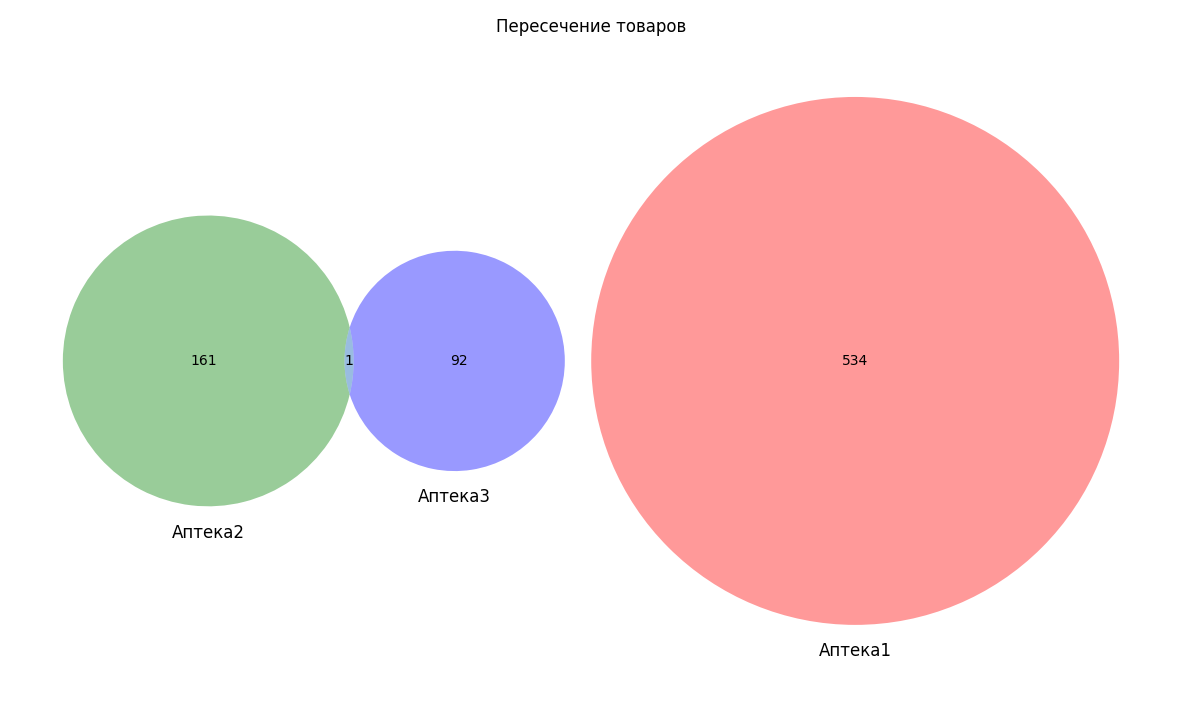
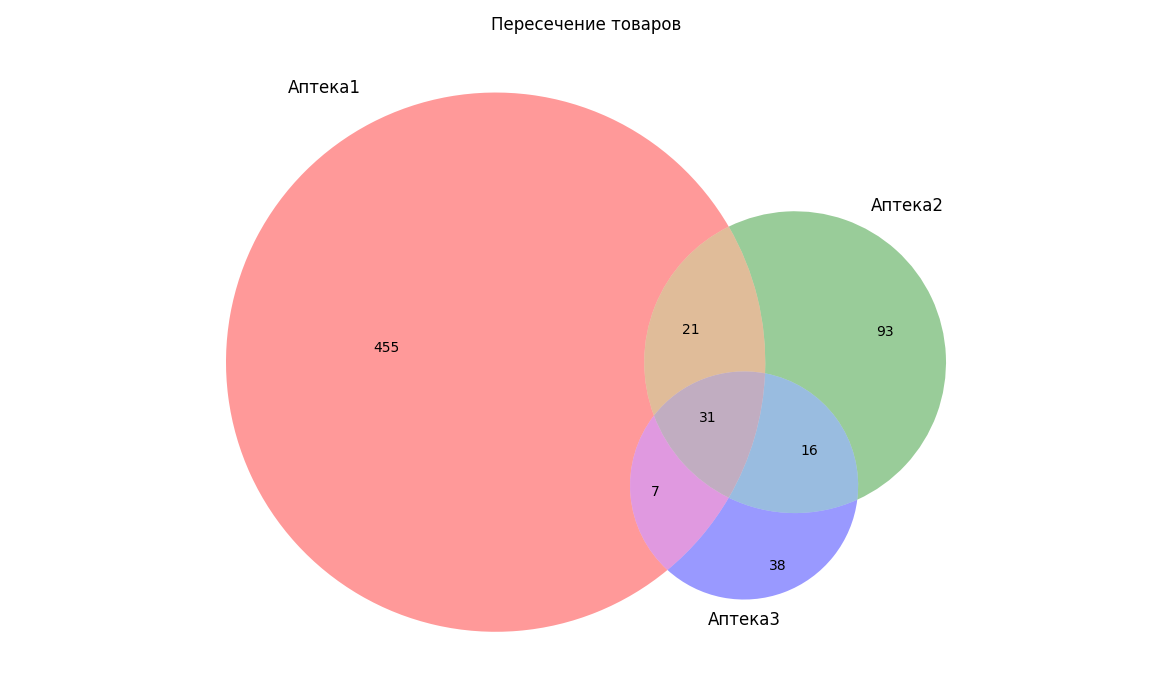

In [ ]:
Пересечений: 31 во всех аптеках
Ошибочных: вроде нет
Все ли пересечния: требует исследования, так как возможно не все вариации имен были учтены
Стоимость: Или Nan, или средняя стоимость выше в аптеках 2 и 3, чем в аптеке 1.
Позиции, что есть:
диазолин таблетки
зиртек таблетки

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re
import seaborn as sns

naming = dict()
naming['г.'] = 'г'
naming['шт.'] = 'шт'
naming['доз.'] = 'доз'
naming['таб.'] = 'таблетки'
naming['капс.'] = 'капсулы'
naming['р-н'] = 'раствор'
naming['р-р'] = 'раствор'
naming['мг.'] = 'мг'
naming['мл.'] = 'мл'
naming['дисперг.'] = 'диспергируемые'
naming['д/наружн.'] = 'для наружного'
naming['наружн.'] = 'наружного'
naming['прим.'] = 'применения' 
naming['д/ин.'] = 'для инъекций' 
naming['в/в'] = 'внутривенного'
naming['в/м'] = 'внутримышечного' 
naming['п/о'] = 'покрытые оболочкой'
naming['пл/о'] = 'покрытые оболочкой'
naming['п/о/о'] = 'покрытые оболочкой'
naming['капс.'] = 'капсулы'


def convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    try:
        price_str = str(price_str).replace(' ', '').replace('₽', '').replace('руб', '').replace(',', '.')
        price_str = re.sub(r'[^\d.-]', '', price_str)
        return float(price_str)
    except:
        return np.nan


first = pd.read_csv('pharmacy1.csv')
second = pd.read_csv('pharmacy2.csv')
third = pd.read_csv('pharmacy3.csv')
for col in first.columns[2:9]:
    first[col] = first[col].apply(convert_price)

second['Цена'] = second['Цена'].apply(convert_price)
third['Цена'] = third['Цена'].apply(convert_price)

def extract_without_percent(s):
    regex = r'\d+(?:[.,]\d+)?'
    values = []
    words = s.split()
    counter = 0
    pot_numbers = re.finditer(regex, s)

    for i in words:
        if counter == 2:
            break
        if not bool(re.search(r'\d', i)):
            if i not in ['мг','мл','г','шт','доз']:
                values.append(i)
                counter += 1
    values.sort()
    
    
    numerical_values = []
    for match in pot_numbers:
        number_str = match.group(0)
        end_pos = match.end()
        following_text = s[end_pos:]
        if not re.match(r'\s*%', following_text):
            numerical_values.append(number_str)
    return ' '.join(values + numerical_values)


def clean_frame(frame):
    clean_copy = frame.copy()
    clean_copy['Наименование'] = clean_copy['Наименование'].apply(clean_name)
    clean_copy['Наименование'] = clean_copy['Наименование'].apply(extract_without_percent)
    return clean_copy

def clean_name(string):
    string = string.lower()
    
    string = string.strip()
    string = ' '.join(string.split())
    string = string.replace(',', ' ')
    string = string.replace('№', ' ')
    string = string.replace('(', ' ')
    string = string.replace(')', ' ')
    string = string.replace('ё', 'е')
    for old, new in naming.items():
        string = string.replace(old, new)
    string = ' '.join(string.split())
    return string

def venns_plot(first, second, third, column):
    set1 = set(first[column].unique())
    set2 = set(second[column].unique())
    set3 = set(third[column].unique())

    plt.figure(figsize=(20, 14))
    diagram = venn3([set1, set2, set3], set_labels=('Аптека1','Аптека2','Аптека3'))
    plt.title('Пересечение товаров')

    plt.tight_layout()
    plt.show()


def intersection_average(first, second, third):
    set1 = set(first['Наименование'].unique())
    set2 = set(second['Наименование'].unique())
    set3 = set(third['Наименование'].unique())

    set_inter = set1 & set2 & set3
    inter = first[first['Наименование'].isin(set_inter)]
    inter['Аптека2'] = second[second['Наименование'].isin(set_inter)]['Цена']
    inter['Аптека3'] = third[third['Наименование'].isin(set_inter)]['Цена']

    return inter




venns_plot(first, second, third, 'Наименование')
clean_first = clean_frame(first)
clean_second = clean_frame(second)
clean_third = clean_frame(third)
clean_two_third = clean_frame(pd.concat([second, third], ignore_index=True))
venns_plot(clean_first, clean_second, clean_third, 'Наименование')




inter = intersection_average(clean_first, clean_second, clean_third)
inter = inter.dropna()
for index, row in inter.iterrows():
    mean = row[1:8].mean()
    print(f'{row[0]}', f'2 {round(row[8] - mean,2)}', f'3 {round(row[8] - mean,2)}')

# Часть 4. Поиск пересечений по лекарстам через N-грамы. 5 баллов.

Теперь попробуем чуть более универсальный способ поиска.

Для простоты будем считать, что в части 3 ты нашёл 100% совпадений и все они корректны (если это не так, то надо, чтобы процент реальных совпадений был выше 95%)

Построй [n-грамы](https://en.wikipedia.org/wiki/N-gram) для названий лекарств (n = 1, 2, 3, 4, 5). Давай считать, что если множества n-грам совпадают на `threshold` долю, то эти позиции совпадающие, а если нет - нет.

Подбери возможные `threshold`ы для различных n.

Визуализируй результаты при помощи matplotlib-venn и для каждого n определи точность. Какой n и `threshold` лучше взять для такого метода, исходя из твоих экспериментов?

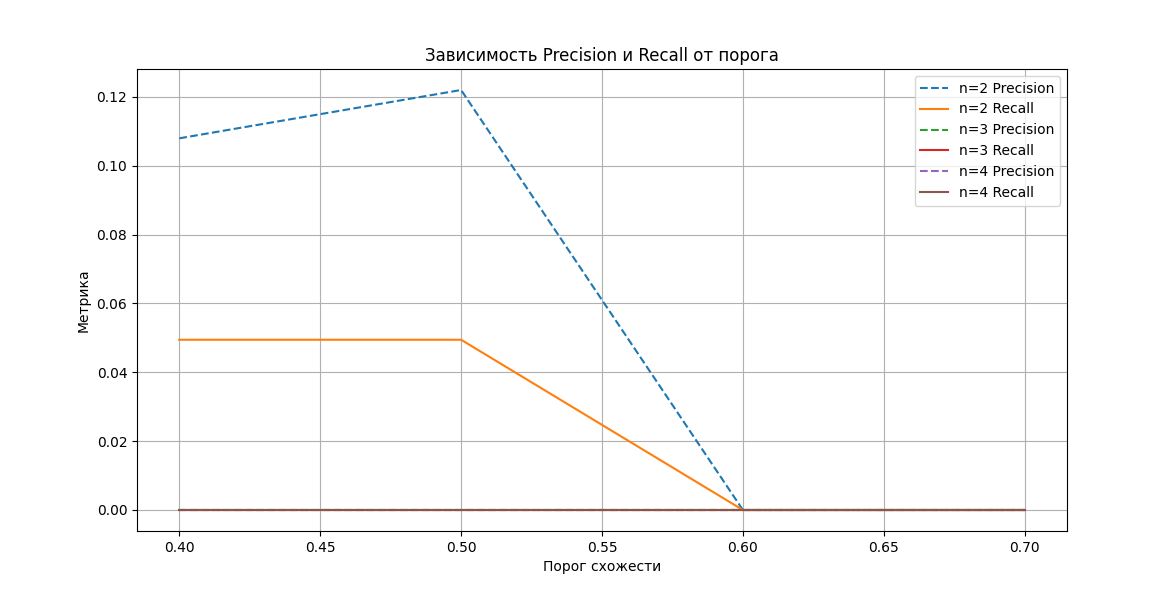
Найдено 31 эталонных совпадений между аптеками 1, 2, 3
Лучшие параметры: n=2, threshold=0.5
Precision: 0.12, Recall: 0.05, F1: 0.07
Найдено совпадений: 377


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re
import seaborn as sns
import string

def convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    try:
        price_str = str(price_str).replace(' ', '').replace('₽', '').replace('руб', '').replace(',', '.')
        price_str = re.sub(r'[^\d.-]', '', price_str)
        return float(price_str)
    except:
        return np.nan

naming = dict()
naming['г.'] = 'г'
naming['шт.'] = 'шт'
naming['доз.'] = 'доз'
naming['таб.'] = 'таблетки'
naming['капс.'] = 'капсулы'
naming['р-н'] = 'раствор'
naming['р-р'] = 'раствор'
naming['мг.'] = 'мг'
naming['мл.'] = 'мл'
naming['дисперг.'] = 'диспергируемые'
naming['д/наружн.'] = 'для наружного'
naming['наружн.'] = 'наружного'
naming['прим.'] = 'применения' 
naming['д/ин.'] = 'для инъекций' 
naming['в/в'] = 'внутривенного'
naming['в/м'] = 'внутримышечного' 
naming['п/о'] = 'покрытые оболочкой'
naming['пл/о'] = 'покрытые оболочкой'
naming['п/о/о'] = 'покрытые оболочкой'
naming['капс.'] = 'капсулы'

first = pd.read_csv('pharmacy1.csv')
second = pd.read_csv('pharmacy2.csv')
third = pd.read_csv('pharmacy3.csv')


for col in first.columns[2:9]:
    first[col] = first[col].apply(convert_price)


second['Цена'] = second['Цена'].apply(convert_price)
third['Цена'] = third['Цена'].apply(convert_price)


def extract_without_percent(s):
    regex = r'\d+(?:[.,]\d+)?'
    values = []
    words = s.split()
    counter = 0
    pot_numbers = re.finditer(regex, s)

    for i in words:
        if counter == 2:
            break
        if not bool(re.search(r'\d', i)):
            if i not in ['мг','мл','г','шт','доз']:
                values.append(i)
                counter += 1
    values.sort()
    
    
    numerical_values = []
    for match in pot_numbers:
        number_str = match.group(0)
        end_pos = match.end()
        following_text = s[end_pos:]
        if not re.match(r'\s*%', following_text):
            numerical_values.append(number_str)
    return ' '.join(values + numerical_values)


def clean_frame(frame):
    clean_copy = frame.copy()
    clean_copy['Наименование'] = clean_copy['Наименование'].apply(clean_name)
    clean_copy['Наименование'] = clean_copy['Наименование'].apply(extract_without_percent)
    return clean_copy

def clean_name(string):
    string = string.lower()
    
    string = string.strip()
    string = ' '.join(string.split())
    string = string.replace(',', ' ')
    string = string.replace('№', ' ')
    string = string.replace('(', ' ')
    string = string.replace(')', ' ')
    string = string.replace('ё', 'е')
    for old, new in naming.items():
        string = string.replace(old, new)
    string = ' '.join(string.split())
    return string

def intersect(first, second, third, column):
    set1 = set(first[column].unique())
    set2 = set(second[column].unique())
    set3 = set(third[column].unique())

    return (set1 & set2 & set3)





clean_first = clean_frame(first)
clean_second = clean_frame(second)
clean_third = clean_frame(third)


perfect_matches = list(intersect(clean_first, clean_second, clean_third, 'Наименование'))

print(f"Найдено {len(perfect_matches)} эталонных совпадений между аптеками 1, 2, 3")

def generate_ngrams(text, n=3):
    text = str(text).lower().translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    return {' '.join(words[i:i+n]) for i in range(len(words)-n+1)}

def calculate_similarity(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union else 0

n_values = [2, 3, 4]
thresholds = [0.4, 0.5, 0.6, 0.7]
results = []

true_positives = set()

for name1 in perfect_matches:
    for name2 in perfect_matches:
        if(name1 != name2):
            true_positives.add((name1, name2))
    

for n in n_values:
    for threshold in thresholds:
        found_matches = set()
        for name1 in clean_first['Наименование'].dropna():
            for name2 in clean_second['Наименование'].dropna():
                if calculate_similarity(generate_ngrams(name1, n), generate_ngrams(name2, n)) >= threshold:
                    found_matches.add((name1, name2))
        
        tp = len(found_matches & true_positives)
        fp = len(found_matches - true_positives)
        fn = len(true_positives - found_matches)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        results.append({
            'n': n,
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'matches': len(found_matches)
        })

best_result = max(results, key=lambda x: x['f1'])
print(f"Лучшие параметры: n={best_result['n']}, threshold={best_result['threshold']}")
print(f"Precision: {best_result['precision']:.2f}, Recall: {best_result['recall']:.2f}, F1: {best_result['f1']:.2f}")
print(f"Найдено совпадений: {best_result['matches']}")


if results:
    plt.figure(figsize=(12, 6))
    for n in n_values:
        n_results = [r for r in results if r['n'] == n]
        if n_results:  
            thresh = [r['threshold'] for r in n_results]
            prec = [r['precision'] for r in n_results]
            rec = [r['recall'] for r in n_results]
            
            plt.plot(thresh, prec, '--', label=f'n={n} Precision')
            plt.plot(thresh, rec, '-', label=f'n={n} Recall')

    plt.xlabel('Порог схожести')
    plt.ylabel('Метрика')
    plt.title('Зависимость Precision и Recall от порога')
    plt.legend()
    plt.grid()
    plt.show()

<font color="violet"> TODO </font>


# Часть 5. Анализ проделанной работы. 1 балл.

В этой части тебе надо:

- проанализировать цены на совпадающие позиции. В какой аптеке лучше закупаться? Есть ли существенная разница между аптеками?
- сравни предложенные методы в частях 3 и 4. Если бы у тебя были датасеты 30 аптек по всем возможным позициям, какой бы способ ты выбрал для поиска пересекающихся товаров?

In [ ]:
--------

<font color="violet"> TODO </font>
